<a href="https://colab.research.google.com/github/xhx/1806/blob/master/day1_intro_to_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1 — A Gentle Introduction to Machine Learning

**AI & ML Summer Academy**

Welcome! This notebook is your very first taste of machine learning. We'll keep the math out of the way for now and focus on the *ideas* and the *data*. By the end you will:

1. Know what a machine learning **dataset** looks like (features + target).
2. Have loaded a real, famous dataset — the **Iris flowers**.
3. Have made your first plots to *look* at data before doing anything fancy with it.

> **How to use this notebook.** Read each markdown cell, then run the code cell below it with `Shift + Enter`. Feel free to change numbers, break things, and re-run — that's the best way to learn.

## 1. What is Machine Learning?

**Machine learning (ML)** is the art of getting computers to *learn patterns from examples* instead of following rules a human wrote by hand.

Traditional programming:

> *You* write the rules → the computer applies them to data → out comes an answer.

Machine learning:

> You show the computer lots of **(data, correct answer)** pairs → it figures out the rules on its own → it can then answer questions about *new* data it has never seen.

### A tiny example
Imagine you want a program that looks at a flower and guesses what species it is. Writing that by hand would be nightmarish — "if the petal is *sort of* long and *kind of* purple..." Instead, we hand the computer 150 flowers that a botanist has already labeled, and let it work out the pattern itself. That is exactly what we'll set up today.

### Key vocabulary
| Word | Meaning | Iris example |
|------|---------|--------------|
| **Sample** (or *example*, *row*) | One thing you measured | One flower |
| **Feature** (or *input*, *X*) | A number describing the sample | Petal length in cm |
| **Target** (or *label*, *y*) | The answer you want to predict | Which species the flower is |
| **Dataset** | A big table of samples | All 150 flowers together |
| **Model** | The pattern-finder the computer trains | (we'll build one on Day 2!) |

Today we're only doing steps *before* the model: **look at the data.** This step is called **exploratory data analysis (EDA)**, and skipping it is one of the most common beginner mistakes.

## 2. Setting Up Our Tools

Before we can do anything, we need to import a few Python libraries. Think of these as toolboxes we're borrowing:

- **`numpy`** — fast math on arrays of numbers.
- **`pandas`** — spreadsheet-style tables (called *DataFrames*).
- **`matplotlib`** and **`seaborn`** — for making plots.
- **`sklearn`** (scikit-learn) — the classic Python ML library. It even ships the Iris dataset built in, so we don't have to download anything.

If any of these are missing on your machine, install them once from a terminal:

```bash
pip install numpy pandas matplotlib seaborn scikit-learn
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

print("All libraries loaded. You're ready to go!")

All libraries loaded. You're ready to go!


## 3. Meet the Iris Dataset

The **Iris dataset** is the "hello world" of machine learning. It was collected by botanist *Edgar Anderson* in 1935 and made famous by statistician *Ronald Fisher* the year after. Almost every ML textbook uses it, so you'll see it again and again.

It contains **150 iris flowers**, 50 each from three species:

- **Iris setosa**
- **Iris versicolor**
- **Iris virginica**

For every flower, four measurements (in centimeters) were recorded:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

<sub>Sepals are the green leaf-like parts that protect the flower bud; petals are the colorful parts.</sub>

So each flower is described by **4 numbers** (the *features*) plus **1 label** (the *species*, the *target*). Our long-term goal in ML will be: *given the 4 numbers for a new flower, predict its species.* But today we're just going to look.

Let's load it.

In [2]:
iris = load_iris()

print("Type of the object we got back:", type(iris))
print("Keys inside it:", list(iris.keys()))

Type of the object we got back: <class 'sklearn.utils._bunch.Bunch'>
Keys inside it: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']


`load_iris()` gives us back a special container (a `Bunch`, which is basically a dictionary). The pieces we care about right now are:

- `iris.data` — the **feature matrix** `X`, shape `(150, 4)`.
- `iris.target` — the **target vector** `y`, shape `(150,)`, with values `0`, `1`, `2`.
- `iris.feature_names` — the names of the 4 columns of `X`.
- `iris.target_names` — the human-readable names for `0/1/2`.

Let's peek at each of them.

In [3]:
X = iris.data
y = iris.target

print("Feature matrix X shape:", X.shape)
print("Target vector y shape: ", y.shape)
print()
print("Feature names:", iris.feature_names)
print("Target names: ", list(iris.target_names))
print()
print("First 5 rows of X:")
print(X[:5])
print()
print("First 5 values of y:", y[:5])

Feature matrix X shape: (150, 4)
Target vector y shape:  (150,)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names:  [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 rows of X:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First 5 values of y: [0 0 0 0 0]


Raw NumPy arrays are fine, but they're a little hard to read. Let's pack everything into a **pandas DataFrame** — think of it as a well-labeled spreadsheet. We'll also add a friendly `species` column with the real names instead of `0/1/2`.

In [4]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in y]

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### 3.1 Quick sanity checks

Before plotting, always answer three basic questions about a new dataset:

1. **How big is it?** (rows and columns)
2. **How is the target distributed?** (are the classes balanced?)
3. **What do the features roughly look like?** (min, max, mean, spread)

In [5]:
print("Rows and columns:", df.shape)
print()
print("Number of flowers per species:")
print(df["species"].value_counts())

Rows and columns: (150, 5)

Number of flowers per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Nice — a few things to notice:

- We have exactly **50 flowers of each species**. That's called a **balanced** dataset, and it makes life easier.
- All four features are on the same rough scale (a few centimeters), so no feature is going to totally dominate the others.
- Petal measurements have a much wider spread than sepal measurements. That's a hint that petals might be more useful for telling species apart. We'll see this visually in a minute.

## 4. Visualizing the Data

Numbers in a table only tell you so much. Plots let your eyes do the pattern-finding, and your eyes are *really* good at it.

We'll make two kinds of plots today:

- **Histograms** — one feature at a time. "How are the values of *this* one measurement spread out?"
- **Scatter plots** — two features at a time. "Does *this* measurement relate to *that* one?"

In both cases we'll color the points by species so we can see whether the species actually *look* different.

### 4.1 Histograms of each feature

A **histogram** chops a range of values into bins and shows how many samples fall in each bin. Tall bar = lots of flowers with that measurement. We'll draw one histogram per feature, and stack the three species on top of each other in different colors.

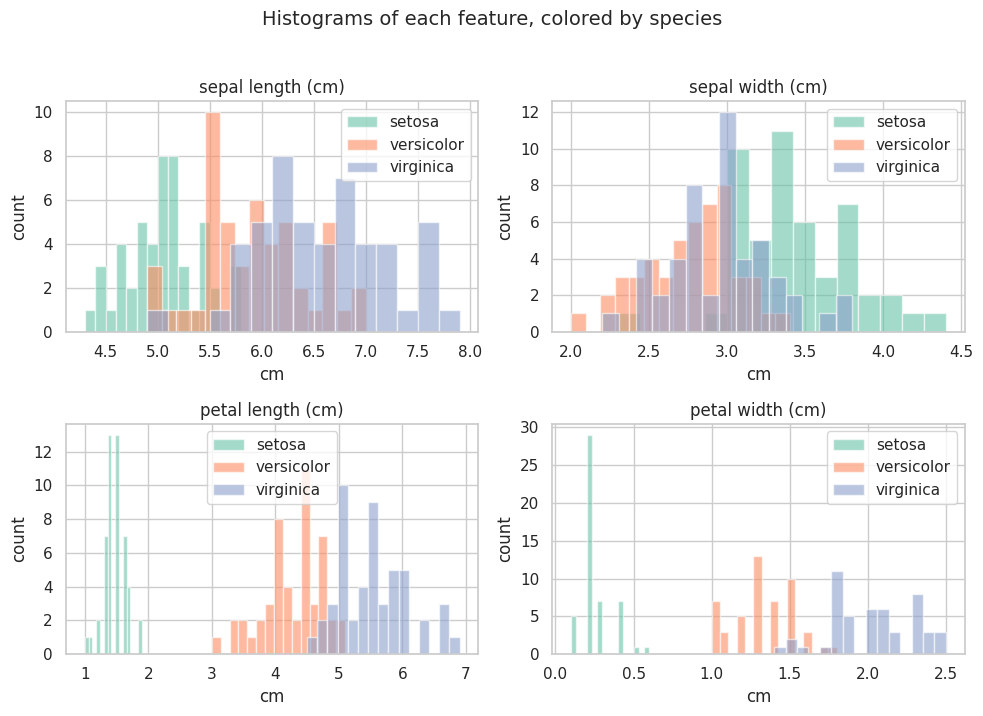

In [7]:
features = iris.feature_names
species_list = list(iris.target_names)
palette = sns.color_palette("Set2", n_colors=3)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    for species, color in zip(species_list, palette):
        subset = df.loc[df["species"] == species, feature]
        ax.hist(subset, bins=15, alpha=0.6, label=species, color=color, edgecolor="white")
    ax.set_title(feature)
    ax.set_xlabel("cm")
    ax.set_ylabel("count")
    ax.legend()

fig.suptitle("Histograms of each feature, colored by species", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

**What to look for in these histograms:**

- If the three colored humps sit on *top* of each other, that feature is **not very helpful** for telling the species apart. (Look at *sepal width* — the three species mostly overlap.)
- If the humps are **separated** along the x-axis, that feature *is* helpful. (Look at *petal length* and *petal width* — setosa is clearly off by itself on the left!)

Already, without any machine learning, we can eyeball a rule like *"if petal length is less than about 2 cm, it's probably setosa."* That's the kind of pattern an ML model will learn automatically, but on much harder datasets where humans can't just look.

### 4.2 Scatter plots between features

A **scatter plot** puts one feature on the x-axis and another on the y-axis, then drops each sample as a dot. It tells us how two features **relate** to each other and — since we'll color by species — whether pairs of features together can separate the classes.

Let's start with a single, telling pair: petal length vs petal width.

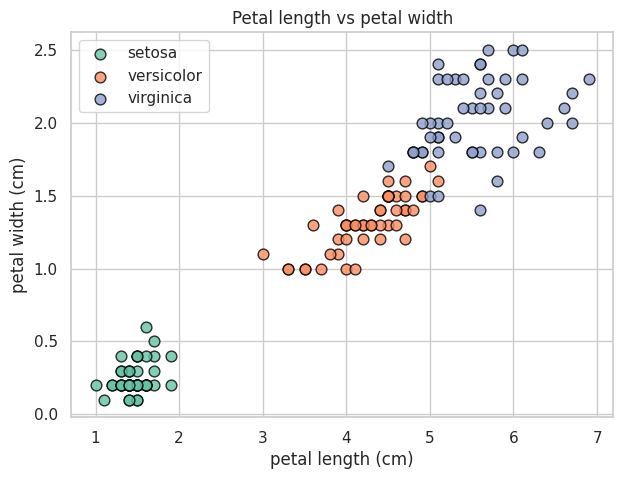

In [8]:
plt.figure(figsize=(7, 5))
for species, color in zip(species_list, palette):
    subset = df[df["species"] == species]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species,
        color=color,
        edgecolor="black",
        s=60,
        alpha=0.8,
    )
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("Petal length vs petal width")
plt.legend()
plt.show()

Look how cleanly *setosa* sits in its own corner, and how *versicolor* and *virginica* form two mostly-separate clouds. Just these **two features alone** are almost enough to classify all 150 flowers correctly. That is a huge deal — it means the problem is genuinely learnable.

Now let's do this for *every* pair of features at once. Seaborn's `pairplot` builds a grid of scatter plots (with histograms on the diagonal, for free).

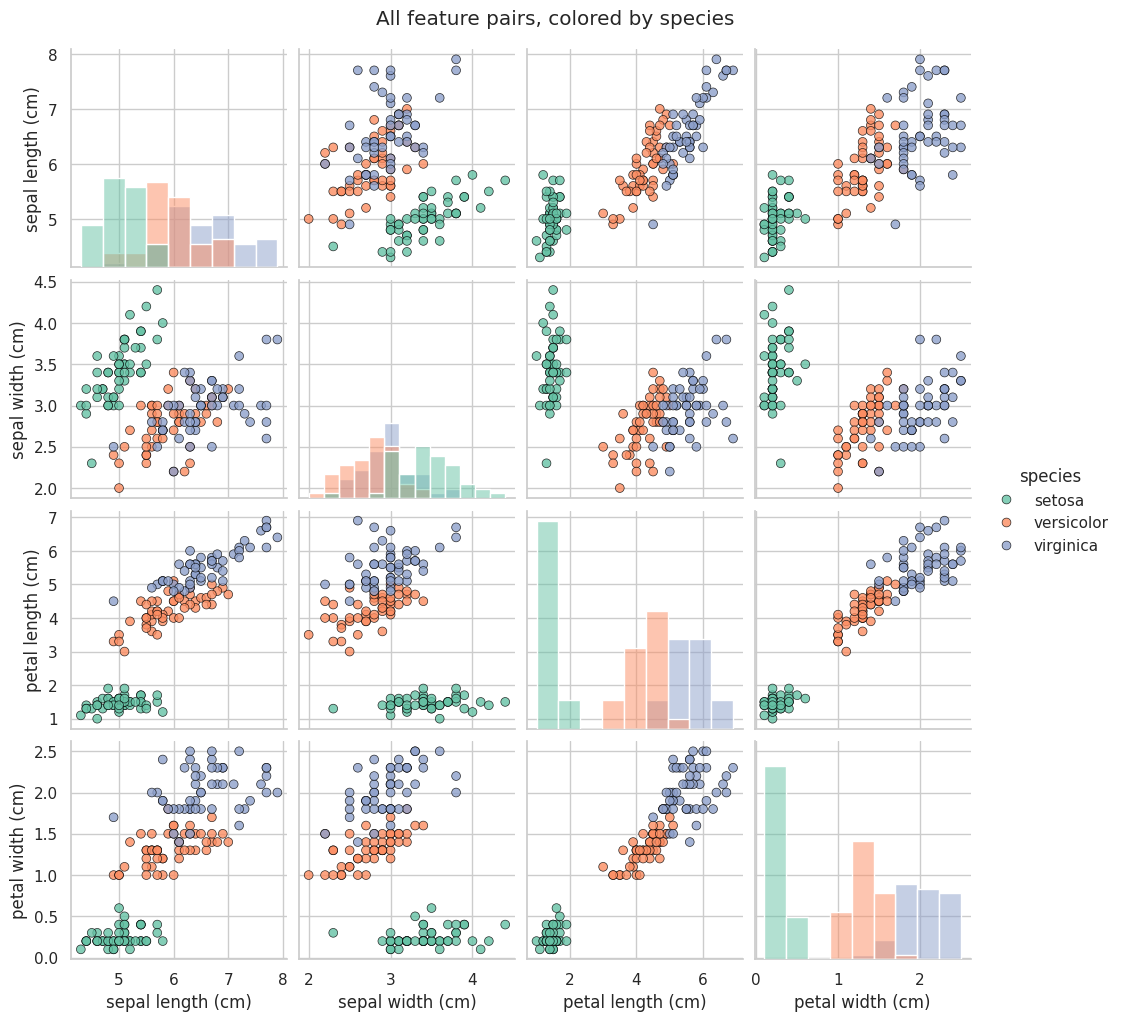

In [9]:
sns.pairplot(
    df,
    hue="species",
    palette="Set2",
    diag_kind="hist",
    plot_kws={"edgecolor": "black", "alpha": 0.8, "s": 40},
)
plt.suptitle("All feature pairs, colored by species", y=1.02)
plt.show()

**How to read this grid:**

- Each **off-diagonal** cell is a scatter plot of one feature vs another.
- Each **diagonal** cell is a histogram of a single feature (like §4.1).
- The grid is symmetric — the plot in row *i*, column *j* has the same information as row *j*, column *i*, just with the axes swapped.

Sweep your eyes across the grid and ask: *for which pair of features are the three colors most cleanly separated?* The petal-length / petal-width panel wins by a mile, and any pair involving petal measurements does well. Sepal-only pairs are much messier — versicolor and virginica overlap a lot.

## 5. Recap

Today you:

- Learned what a **dataset**, a **feature**, and a **target** are.
- Loaded a real dataset (**Iris**, 150 flowers × 4 features + 1 label) from scikit-learn.
- Turned it into a tidy pandas DataFrame and ran basic sanity checks.
- Drew **histograms** to see how single features are distributed per species.
- Drew **scatter plots** (and a full pairplot) to see how pairs of features together separate the species.

Big takeaway: **before you train any model, look at your data.** You just found out — with your eyes — that petal measurements carry most of the signal for this problem. A model will "discover" the same thing on Day 2, and you'll have an intuition for *why* it works.

## 6. Try It Yourself

A few tiny challenges to make sure the ideas stuck. Add code cells below and give them a shot:

1. **Change the histogram bin count** from `bins=15` to `bins=5` and then `bins=40`. What changes? What stays the same?
2. Make a scatter plot of **sepal length vs sepal width**. Can you draw a straight line by eye that separates the three species? (You'll find it's hard!)
3. Compute the **average petal length for each species** with `df.groupby("species")["petal length (cm)"].mean()`. Do the numbers match what you saw in the histograms?
4. What single feature would you pick if you were only allowed one to guess the species? Justify your choice from the plots.